# GeoLife CP1 — Cleaning + Stay-point Validation

**Mục tiêu:** kiểm chứng rằng cleaning + stay-point detector trong `src/geolife/` thực hiện đúng contract đã hình thành từ EDA, rồi đo tác động của contract đó trên release GeoLife thật.

Notebook này trả lời bốn câu hỏi:

1. các edge case quan trọng có đúng semantics đã review không;
2. cleaning có tạo continuity boundary đúng chỗ mà không đoán endpoint nào “sai” không;
3. stay detector có tôn trọng sequence boundary và dwell semantics không;
4. baseline `10 m / 300 s / 1200 km/h / 200 m / 20 min` có chạy ổn trên toàn release trước khi sensitivity ở notebook 02b.

> **Source of truth:** notebook không chứa implementation thứ hai. Mọi transform đều import trực tiếp từ `src/geolife/`, vì vậy output notebook là validation của production code chứ không phải một pipeline song song.

> **Không phải accuracy benchmark:** GeoLife không có Home/Office ground truth cho stage này. Số stay nhiều hơn không đồng nghĩa tốt hơn.

## Cách chạy

Thiết kế theo workflow notebook EDA hiện tại:

- ưu tiên Modal volume tại `/mnt/geolife-data`;
- hỗ trợ `GEOLIFE_DATA_ROOT` và `GEOLIFE_REPO_DIR` khi chạy nơi khác;
- clone/pull repo branch được chỉ định qua `GEOLIFE_REPO_BRANCH`; sau khi CP1/CP2 merge, mặc định nên dùng `main`;
- cache output đắt tiền dưới volume;
- có thể chạy `Run All` từ đầu đến cuối.

Baseline ban đầu:

- same-second radius: **10 m**
- max gap: **300 s**
- hard-speed guard: **1200 km/h**
- stay distance: **200 m**
- min dwell: **1200 s (20 phút)**


Các full-scan output đắt tiền được cache dưới volume. Notebook 02b mới là sensitivity run cuối dùng deterministic user-stratified sample; sensitivity subset ở cuối notebook này chỉ là mechanics smoke check.

In [1]:
from pathlib import Path
from time import perf_counter
from IPython.display import display, Markdown
import os
import subprocess
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

REPO_URL = "https://github.com/tanh1c/geolife.git"
REPO_BRANCH = os.environ.get("GEOLIFE_REPO_BRANCH", "main")
REPO_DIR = Path(os.environ.get("GEOLIFE_REPO_DIR", "/tmp/geolife"))
CACHE_DIR = Path(os.environ.get("GEOLIFE_CACHE_DIR", "/mnt/geolife-data/cache/cp1_staypoints"))
CACHE_DIR.mkdir(parents=True, exist_ok=True)

def resolve_data_root() -> Path:
    env_root = os.environ.get("GEOLIFE_DATA_ROOT")
    candidates = []
    if env_root:
        candidates.append(Path(env_root))
    candidates.extend([
        Path("/mnt/geolife-data/extracted/Geolife Trajectories 1.3/Data"),
        Path("/mnt/geolife-data/Data"),
        Path("/mnt/geolife-data/extracted/Data"),
    ])

    checked = []
    for candidate in candidates:
        checked.append(str(candidate))
        if candidate.is_dir() and any(candidate.glob("*/Trajectory/*.plt")):
            return candidate

    volume_root = Path("/mnt/geolife-data")
    if volume_root.is_dir():
        for candidate in sorted(volume_root.glob("**/Data")):
            if candidate.is_dir() and any(candidate.glob("*/Trajectory/*.plt")):
                return candidate

    raise FileNotFoundError(
        "Không tìm thấy GeoLife Data folder có */Trajectory/*.plt. "
        f"Đã kiểm tra: {checked}. Set GEOLIFE_DATA_ROOT nếu dataset nằm nơi khác."
    )

def ensure_repo():
    if (REPO_DIR / ".git").exists():
        subprocess.run(["git", "-C", str(REPO_DIR), "fetch", "origin"], check=True)
        subprocess.run(["git", "-C", str(REPO_DIR), "checkout", REPO_BRANCH], check=True)
        subprocess.run(["git", "-C", str(REPO_DIR), "pull", "--ff-only", "origin", REPO_BRANCH], check=True)
    else:
        subprocess.run(["git", "clone", "--branch", REPO_BRANCH, REPO_URL, str(REPO_DIR)], check=True)

DATA_ROOT = resolve_data_root()
ensure_repo()
src_dir = REPO_DIR / "src"
if str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))

from geolife.staypoints import clean_trajectory, detect_staypoints

print("Repo:", REPO_DIR)
print("Branch:", REPO_BRANCH)
print("Data root:", DATA_ROOT)
print("Cache:", CACHE_DIR)


Cloning into '/tmp/geolife'...


Repo: /tmp/geolife
Branch: main
Data root: /mnt/geolife-data/extracted/Geolife Trajectories 1.3/Data
Cache: /mnt/geolife-data/cache/cp1_staypoints


# 1. Contract + baseline configuration

### Câu hỏi

Ta đang validate **parameter values** hay đang thay đổi **algorithm semantics**?

### Tại sao quan trọng?

Hai việc này phải tách nhau:

- `same_second_radius_m=10`: ngưỡng **safe-to-collapse**, không phải valid-vs-corrupt threshold;
- `max_gap_s=300`: quá khoảng này ta không có đủ evidence để nối chuyển động liên tục;
- `hard_speed_guard_kmh=1200`: guard cực rộng để cắt impossible inter-timestamp jumps, không phải transport classifier;
- `distance_threshold_m=200`: spatial membership của một stay candidate;
- `min_dwell_s=1200`: yêu cầu ở lại ít nhất 20 phút.

Notebook chỉ kiểm chứng implementation đã được contract hóa. Tuning value không được âm thầm đổi anchor-based detector, boundary semantics hay dwell definition.

In [2]:
BASELINE = {
    "same_second_radius_m": 10.0,
    "max_gap_s": 300.0,
    "hard_speed_guard_kmh": 1200.0,
    "distance_threshold_m": 200.0,
    "min_dwell_s": 1200.0,
}
BASELINE


{'same_second_radius_m': 10.0,
 'max_gap_s': 300.0,
 'hard_speed_guard_kmh': 1200.0,
 'distance_threshold_m': 200.0,
 'min_dwell_s': 1200.0}

### Cách đọc baseline

Pipeline theo thứ tự:

```text
raw GPS
  ↓ coordinate validation
valid observations
  ↓ same-second consolidation / ambiguity boundary
timestamp-level observations
  ↓ temporal gap + hard-speed continuity guards
clean sequences
  ↓ anchor-based 200 m / 20 min stay detector
stay events
```

Mỗi stage trả lời một loại uncertainty khác nhau. Ta không dùng một rule kiểu `speed > X => drop point`, vì speed anomaly chỉ cho biết **đoạn nối không đáng tin**, không xác định endpoint nào sai.

# 2. Synthetic acceptance smoke tests

Các ví dụ dưới đây phản ánh đúng các semantics đã review trước khi chạy full dataset.


#### 1. Invalid coordinate + Temporal gap

In [3]:
def frame(rows):
    return pd.DataFrame(rows, columns=["timestamp", "latitude", "longitude"]).assign(
        timestamp=lambda x: pd.to_datetime(x["timestamp"], utc=True)
    )

# Invalid coordinate -> boundary
raw = frame([
    ("2026-01-01T10:00:00Z", 39.0, 116.0),
    ("2026-01-01T10:01:00Z", 39.0, 116.0),
    ("2026-01-01T10:02:00Z", 200.0, 116.0),
    ("2026-01-01T10:03:00Z", 39.0, 116.0),
    ("2026-01-01T10:24:00Z", 39.0, 116.0),
])
clean = clean_trajectory(raw)
display(clean)
assert clean["sequence_id"].tolist() == [0, 0, 1, 2]


,timestamp,latitude,longitude,raw_point_count,max_radius_m,sequence_id,boundary_before_reason
0,2026-01-01 10:00:00+00:00,39.0,116.0,1,0.0,0,None
1,2026-01-01 10:01:00+00:00,39.0,116.0,1,0.0,0,None
2,2026-01-01 10:03:00+00:00,39.0,116.0,1,0.0,1,invalid_coordinate
3,2026-01-01 10:24:00+00:00,39.0,116.0,1,0.0,2,temporal_gap


Lưu ý: ví dụ trên cố tình có thêm gap 21 phút sau `C`, nên ngoài boundary do invalid coordinate còn có boundary temporal gap. Đây là check tốt để thấy các stage compose tuần tự thay vì che lấp nhau.


#### 2. Same-second merge

In [4]:
# Compact same-second -> one representative
raw = frame([
    ("2026-01-01T10:00:00Z", 39.000000, 116.000000),
    ("2026-01-01T10:00:00Z", 39.000020, 116.000010),
    ("2026-01-01T10:00:00Z", 39.000010, 116.000020),
])
compact = clean_trajectory(raw)
display(compact)
assert len(compact) == 1
assert int(compact.iloc[0]["raw_point_count"]) == 3
assert compact.iloc[0]["max_radius_m"] <= 10.0


,timestamp,latitude,longitude,raw_point_count,max_radius_m,sequence_id,boundary_before_reason
0,2026-01-01 10:00:00+00:00,39.00001,116.00001,3,1.408257,0,None


#### 3. Terminal Stay

In [5]:
# Terminal valid stay must be emitted
points = pd.DataFrame([
    ("2026-01-01T10:00:00Z", 39.0000, 116.0, 0),
    ("2026-01-01T10:07:00Z", 39.0002, 116.0, 0),
    ("2026-01-01T10:14:00Z", 39.0004, 116.0, 0),
    ("2026-01-01T10:21:00Z", 39.0006, 116.0, 0),
], columns=["timestamp", "latitude", "longitude", "sequence_id"])
points["timestamp"] = pd.to_datetime(points["timestamp"], utc=True)

stays = detect_staypoints(points, distance_threshold_m=200, min_dwell_s=1200)
display(stays)
assert len(stays) == 1
assert stays.iloc[0]["duration_s"] == 1260


,sequence_id,arrival_time,departure_time,duration_s,latitude,longitude,n_points
0,0,2026-01-01 10:00:00+00:00,2026-01-01 10:21:00+00:00,1260.0,39.0003,116.0,4


#### Vì sao cần test terminal stay?

Stay này kéo dài từ **10:00 đến 10:21**, tức:

```text
21 phút = 1260 giây > min_dwell_s = 1200 giây
```

Tất cả 4 points vẫn nằm trong radius 200 m, nên đây là một stay hợp lệ.

Điểm quan trọng là stay nằm **ở cuối sequence**. Không có point tiếp theo đi ra ngoài radius để “đóng” candidate.

Detector vẫn phải emit stay khi hết sequence:

```text
candidate đang hợp lệ
+ dwell đủ dài
+ sequence kết thúc
→ emit stay
```

Nếu implementation chỉ emit khi gặp một outside-radius point, terminal stay này sẽ bị mất.

Output đúng là:

* `arrival_time = 10:00`
* `departure_time = 10:21`
* `duration_s = 1260`
* `n_points = 4`

`departure_time` ở đây là **last observed point**, không có nghĩa user thực sự rời location đúng lúc 10:21.


#### 4. First outside-radius point closes candidate

In [6]:
# First outside-radius point closes candidate; later return cannot bridge it.
points = pd.DataFrame([
    ("2026-01-01T10:00:00Z", 39.0000, 116.0, 0),
    ("2026-01-01T10:05:00Z", 39.0009, 116.0, 0),
    ("2026-01-01T10:10:00Z", 39.0016, 116.0, 0),
    ("2026-01-01T10:15:00Z", 39.0020, 116.0, 0),
    ("2026-01-01T10:21:00Z", 39.0004, 116.0, 0),
], columns=["timestamp", "latitude", "longitude", "sequence_id"])
points["timestamp"] = pd.to_datetime(points["timestamp"], utc=True)

assert detect_staypoints(points, distance_threshold_m=200, min_dwell_s=1200).empty
print("Synthetic smoke tests: OK")


Synthetic smoke tests: OK


#### Vì sao outside-radius point phải đóng candidate?

Stay detector dùng một **anchor point** để mở candidate. Các point sau chỉ được nối vào candidate khi còn nằm trong `distance_threshold_m = 200m`.

Trong ví dụ này:

```text
10:00  → 10:05 → 10:10 → 10:15 → 10:21
 anchor                         ↘ quay lại gần anchor
```

Điểm `10:15` là point đầu tiên vượt ra ngoài bán kính 200 m so với anchor, nên candidate phải **đóng ngay tại đó**.

Point `10:21` dù quay trở lại gần anchor cũng không được phép “bridge” qua point outside-radius trước đó để tạo một stay dài từ `10:00 → 10:21`.

Nếu cho phép bridge như vậy, detector sẽ vô tình biến:

```text
ở gần → rời khỏi vùng → quay lại
```

thành:

```text
ở liên tục một chỗ
```

dù continuity đã bị phá vỡ.

Candidate trước khi bị đóng cũng chưa đạt `min_dwell_s = 1200s`, nên không emit stay nào.

Vì vậy expected result là:

```python
detect_staypoints(...).empty == True
```

Invariant cần giữ:

```text
first outside-radius point
→ đóng candidate hiện tại
→ later return phải bắt đầu candidate mới
→ không được nối ngược qua boundary đó
```


### Kết luận phần 2 — synthetic semantics

Bốn behavior được khóa ở đây:

1. **Invalid coordinate tạo boundary**: observation ngoài domain bị loại nhưng hai phía không được nối xuyên qua nó.
2. **Compact same-second group được collapse**: nhiều rows cùng timestamp trong 10 m trở thành một median representative và giữ `raw_point_count`.
3. **Terminal stay không bị mất**: candidate ở cuối sequence vẫn phải được evaluate dù không có outside point tiếp theo để “đóng” nó.
4. **First outside-radius point closes candidate**: nếu trajectory rời khỏi anchor radius, một lần quay lại sau đó không được bridge ngược qua khoảng rời khỏi location.

Điểm 3 và 4 đặc biệt quan trọng vì đây là hai lỗi off-by-one / bridging rất dễ xuất hiện trong stay-point implementations.

**Không được suy ra:** synthetic PASS không chứng minh threshold 200 m hay 20 phút là accuracy-optimal; nó chỉ chứng minh code thực hiện đúng semantics.

# 3. GeoLife loader

Phần này đọc các file `.plt` của GeoLife và chuyển chúng thành dữ liệu đầu vào cho bước cleaning.

Ở CP1, ta chỉ cần 3 cột:

- `timestamp`: thời điểm GPS được ghi lại
- `latitude`: vĩ độ
- `longitude`: kinh độ

Các cột khác của file GeoLife chưa cần dùng ở bước này nên được bỏ đi.

## Vì sao timestamp được giữ ở UTC?

Sau khi đọc file, `timestamp` được chuyển thành dạng **timezone-aware UTC**.

Ở giai đoạn cleaning và stay-point detection, ta chủ yếu cần biết:

```text
point nào xảy ra trước / sau
và hai point cách nhau bao nhiêu giây
```

Ví dụ:

```text
10:00 → 10:05 = 5 phút
```

Khoảng thời gian này không thay đổi dù biểu diễn ở UTC hay giờ Bắc Kinh.

Vì vậy CP1 giữ toàn bộ timestamp ở UTC để tránh convert timezone quá sớm.

Việc đổi sang giờ địa phương chỉ cần thiết ở bước Home/Office, khi ta bắt đầu hỏi các câu như:

```text
stay này xảy ra ban đêm?
stay này có nằm trong giờ làm việc?
```

## Vì sao phải kiểm tra số lượng file trước khi cache?

Notebook kiểm tra rằng thư mục GeoLife thực sự chứa đủ trajectory files trước khi tạo cache.

Mục đích là tránh trường hợp mount hoặc đường dẫn bị sai:

```text
đường dẫn sai
→ đọc được 0 file
→ tạo cache rỗng
→ lần chạy sau lại load cache rỗng
```

Khi đó pipeline có thể chạy tiếp mà lỗi thật sự rất khó phát hiện.

Vì vậy sanity check này giúp **fail sớm nếu dataset chưa được mount hoặc tìm thấy đúng cách**, trước khi tạo cache.


In [7]:
def read_plt(path: Path) -> pd.DataFrame:
    df = pd.read_csv(
        path,
        skiprows=6,
        header=None,
        names=["latitude", "longitude", "unused", "altitude", "date_days", "date", "time"],
    )
    df["timestamp"] = pd.to_datetime(df["date"] + " " + df["time"], utc=True)
    return df[["timestamp", "latitude", "longitude"]]

def trajectory_files(data_root: Path):
    return sorted(data_root.glob("*/Trajectory/*.plt"))

files = trajectory_files(DATA_ROOT)
user_dirs = sorted(p for p in DATA_ROOT.iterdir() if p.is_dir() and p.name.isdigit())
print("User dirs:", len(user_dirs))
print("Trajectory files:", len(files))

if not files:
    raise RuntimeError(
        f"DATA_ROOT={DATA_ROOT} không chứa trajectory .plt. "
        "Dừng tại đây để tránh tạo cache rỗng."
    )

print("Example:", files[0])


User dirs: 182
Trajectory files: 18670


# 4. Cleaning trên trajectory thật

Bắt đầu bằng một vài file để audit schema, sequence boundaries và diagnostic reasons trước khi full scan.


In [8]:
sample_files = files[:5]
sample_rows = []
for path in sample_files:
    raw = read_plt(path)
    cleaned = clean_trajectory(
        raw,
        same_second_radius_m=BASELINE["same_second_radius_m"],
        max_gap_s=BASELINE["max_gap_s"],
        hard_speed_guard_kmh=BASELINE["hard_speed_guard_kmh"],
    )
    sample_rows.append({
        "file": str(path),
        "raw_rows": len(raw),
        "clean_rows": len(cleaned),
        "sequences": cleaned["sequence_id"].nunique() if len(cleaned) else 0,
        "boundaries": int(cleaned["boundary_before_reason"].notna().sum()) if len(cleaned) else 0,
    })

display(pd.DataFrame(sample_rows))


,file,raw_rows,clean_rows,sequences,boundaries
0,/mnt/geolife-data/extracted/Geolife Trajectori...,908,908,7,6
1,/mnt/geolife-data/extracted/Geolife Trajectori...,244,244,3,2
2,/mnt/geolife-data/extracted/Geolife Trajectori...,745,745,1,0
3,/mnt/geolife-data/extracted/Geolife Trajectori...,50,50,1,0
4,/mnt/geolife-data/extracted/Geolife Trajectori...,1477,1477,4,3


### Cách đọc cleaning sample

Với mỗi file, quan tâm đến bốn cột:

- `raw_rows`: số observations gốc;
- `clean_rows`: số timestamp-level observations còn lại sau validation/consolidation;
- `sequences`: số continuity segments độc lập;
- `boundaries`: số retained rows có `boundary_before_reason`.

> `boundary_before_reason` là diagnostic gắn lên **retained row kế tiếp**, không phải complete event ledger. Một ambiguity ở cuối file hoặc nhiều discarded events trước cùng một retained row có thể không được đếm đầy đủ ở đây. Khi cần event-complete audit phải dùng `clean_trajectory_with_audit()` như notebook 02b.

**Mục tiêu của sample này:** phát hiện schema/pathology trước full scan, không dùng 5 file đầu để suy ra distribution toàn dataset.

# 5. Stay-point detector trên vài trajectory thật

Mục tiêu ở bước này là sanity-check output, chưa phải benchmark Home/Office.


In [9]:
stay_samples = []
for path in sample_files:
    cleaned = clean_trajectory(read_plt(path))
    stays = detect_staypoints(
        cleaned,
        distance_threshold_m=BASELINE["distance_threshold_m"],
        min_dwell_s=BASELINE["min_dwell_s"],
    )
    if len(stays):
        x = stays.copy()
        x["file"] = str(path)
        stay_samples.append(x)

sample_stays = pd.concat(stay_samples, ignore_index=True) if stay_samples else pd.DataFrame()
display(sample_stays.head(30))
print("Sample stays:", len(sample_stays))


Sample stays: 1


Exact sample stay timestamp/coordinates/source path omitted from committed notebook for privacy.


### Cách đọc stay output

Mỗi row stay đại diện cho một interval đã thỏa:

```text
mọi member được xét theo anchor-based radius
+ cùng clean sequence
+ dwell >= 1200 s
```

`arrival_time` / `departure_time` là UTC timestamps của evidence interval; `duration_s` là elapsed time giữa hai mốc đó; coordinate đại diện là robust location của stay.

**Không phải semantic label:** một stay chưa phải HOME hay OFFICE. Một user có thể ghé cùng một nơi nhiều lần, đi du lịch, ở khách sạn, hoặc có ít history. Semantic inference chỉ bắt đầu ở notebook 03.

# 6. Full-release baseline audit

### Câu hỏi

Production pipeline có chạy qua **toàn bộ 18,670 files** mà không lộ pathology rõ ràng không, và frozen config tạo ra baseline nào để downstream so sánh?

Cell này là full scan đắt tiền nên cache summary theo file. Cache chỉ được chấp nhận nếu schema đúng và số rows khớp số trajectory files hiện tại.

### Chú ý về diagnostic counts

`same_second_conflict_boundaries` là tên legacy của cache column; event reason production đã đổi thành `same_second_spatial_ambiguity`. Quan trọng hơn, attached boundary counts không phải complete event counts — notebook 02b dùng audit API để reconcile terminal/multiple events.

In [10]:
BASELINE_CACHE = CACHE_DIR / "baseline_summary_v2.pkl"
BASELINE_COLUMNS = [
    "file",
    "raw_rows",
    "clean_rows",
    "n_sequences",
    "n_stays",
    "invalid_coordinate_boundaries",
    "same_second_conflict_boundaries",
    "temporal_gap_boundaries",
    "hard_speed_boundaries",
]

def run_full_baseline(files):
    rows = []
    for i, path in enumerate(files, start=1):
        raw = read_plt(path)
        cleaned = clean_trajectory(
            raw,
            same_second_radius_m=BASELINE["same_second_radius_m"],
            max_gap_s=BASELINE["max_gap_s"],
            hard_speed_guard_kmh=BASELINE["hard_speed_guard_kmh"],
        )
        stays = detect_staypoints(
            cleaned,
            distance_threshold_m=BASELINE["distance_threshold_m"],
            min_dwell_s=BASELINE["min_dwell_s"],
        )
        reasons = cleaned["boundary_before_reason"].value_counts(dropna=True).to_dict()
        rows.append({
            "file": str(path),
            "raw_rows": len(raw),
            "clean_rows": len(cleaned),
            "n_sequences": cleaned["sequence_id"].nunique() if len(cleaned) else 0,
            "n_stays": len(stays),
            "invalid_coordinate_boundaries": reasons.get("invalid_coordinate", 0),
            "same_second_conflict_boundaries": reasons.get("same_second_spatial_ambiguity", 0),
            "temporal_gap_boundaries": reasons.get("temporal_gap", 0),
            "hard_speed_boundaries": reasons.get("hard_speed_guard", 0),
        })
        if i % 500 == 0:
            print(f"{i:,}/{len(files):,}")
    return pd.DataFrame(rows, columns=BASELINE_COLUMNS)

def baseline_cache_is_valid(df: pd.DataFrame, files) -> bool:
    return (
        list(df.columns) == BASELINE_COLUMNS
        and len(df) == len(files)
        and len(df) > 0
    )

baseline_summary = None
if BASELINE_CACHE.exists():
    cached = pd.read_pickle(BASELINE_CACHE)
    if baseline_cache_is_valid(cached, files):
        baseline_summary = cached
        print("Loaded valid cache:", BASELINE_CACHE)
    else:
        print(
            "Ignoring stale/invalid cache:", BASELINE_CACHE,
            f"(rows={len(cached):,}, expected={len(files):,})"
        )

if baseline_summary is None:
    t0 = perf_counter()
    baseline_summary = run_full_baseline(files)
    if not baseline_cache_is_valid(baseline_summary, files):
        raise RuntimeError(
            f"Full baseline produced invalid summary: rows={len(baseline_summary):,}, "
            f"expected={len(files):,}. Cache was not written."
        )
    baseline_summary.to_pickle(BASELINE_CACHE)
    print(f"Saved {BASELINE_CACHE} in {(perf_counter()-t0)/60:.1f} min")

display(baseline_summary.describe(include="all"))


Loaded valid cache: /mnt/geolife-data/cache/cp1_staypoints/baseline_summary_v2.pkl


,file,raw_rows,clean_rows,n_sequences,n_stays,invalid_coordinate_boundaries,same_second_conflict_boundaries,temporal_gap_boundaries,hard_speed_boundaries
count,18670,18670.000000,18670.000000,18670.000000,18670.000000,18670.000000,18670.000000,18670.000000,18670.000000
unique,18670,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,/mnt/geolife-data/extracted/Geolife Trajectori...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,1332.457311,1294.978147,3.212748,0.311784,0.000054,0.036583,2.128709,0.048420
std,NaN,2821.513811,2683.924376,6.321425,1.257302,0.007319,0.522257,4.296560,4.357456
min,NaN,3.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,NaN,201.000000,200.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,NaN,506.000000,504.000000,2.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,NaN,1367.000000,1339.750000,4.000000,0.000000,0.000000,0.000000,2.000000,0.000000


### Cách đọc bảng full-baseline summary

Mỗi dòng của `baseline_summary` tương ứng với **một trajectory file**.  
`describe()` sau đó tóm tắt toàn bộ 18,670 files.

Các thống kê chính:

- `count`: số file có giá trị
- `mean`: trung bình trên mỗi file
- `25%`: 25% số file có giá trị nhỏ hơn hoặc bằng mức này
- `50%`: median — một nửa số file nằm dưới mức này
- `75%`: 75% số file nằm dưới mức này
- `max`: giá trị lớn nhất quan sát được

### Ý nghĩa từng cột

**`raw_rows`** — số GPS points trước cleaning.

- trung bình: `1332`
- median: `506`
- lớn nhất: `92645`

Dataset có kích thước file rất không đồng đều: phần lớn file khá nhỏ, nhưng có một số file rất lớn.

**`clean_rows`** — số observations còn lại sau cleaning.

- trung bình: `1295`
- median: `504`

`clean_rows` chỉ thấp hơn `raw_rows` một chút, cho thấy cleaning chủ yếu bảo toàn dữ liệu thay vì loại bỏ hàng loạt points.

**`n_sequences`** — số đoạn trajectory liên tục còn lại sau khi cleaning tạo các boundary.

- median: `2`
- trung bình: `3.21`
- lớn nhất: `623`

Một file có thể bị chia thành nhiều sequence khi gặp temporal gap, spatial ambiguity hoặc hard-speed boundary.

**`n_stays`** — số stay points được phát hiện trong file.

- median: `0`
- trung bình: `0.31`
- lớn nhất: `57`

Median bằng `0` nghĩa là hơn một nửa trajectory files không tạo ra stay nào với baseline `200 m / 20 phút`. Đây không nhất thiết là lỗi: nhiều file chỉ ghi lại các đoạn di chuyển hoặc không đủ dwell time.

### Các loại boundary

`invalid_coordinate_boundaries`

Gần như bằng 0 ở hầu hết files. Tọa độ không hợp lệ rất hiếm trong release này.

`same_second_conflict_boundaries`

Median bằng 0 và mean khoảng `0.037/file`, nghĩa là spatial ambiguity trong cùng một timestamp có tồn tại nhưng không phổ biến.

Tên cột này là tên lịch sử; production reason hiện là:

`same_second_spatial_ambiguity`

`temporal_gap_boundaries`

Đây là boundary phổ biến nhất:

- median: `1`
- mean: `2.13`
- max: `196`

Nghĩa là nhiều trajectory files chứa các khoảng thời gian mất quan sát lớn hơn baseline `300 s`, nên cần tách continuity sequence.

`hard_speed_boundaries`

Phần lớn files không có:

- median: `0`
- 75%: `0`

nhưng có một số outlier mạnh, với một file đạt tới `593` boundaries. Đây là lý do ta giữ hard-speed guard như một cơ chế bảo vệ thay vì giả định mọi trajectory đều sạch.

### Kết luận chính

Full-release run cho thấy:

```text
18,670 trajectory files
~24.9M raw GPS points
~24.2M cleaned observations
5,821 detected stays

### Kết quả full-release đã audit

Run production baseline trên toàn release cho:

- **18,670 trajectory files** được xử lý;
- **5,821 stays**;
- **2,435 files** có ít nhất một stay;
- hard-speed corruption tập trung mạnh: trajectory pathology lớn nhất có **593 hard-speed boundaries**.

Điểm quan trọng không phải chỉ là `5,821`. Full scan chứng minh pipeline có thể materialize một baseline hữu hạn, deterministic và traceable trên toàn release mà không cần xóa hàng loạt points theo transport-speed thresholds.

### Cách diễn giải hard-speed guard

`1200 km/h` là một guard cực rộng. Nó cố ý nằm trên observed airplane speed trong audited labels để tránh biến ordinary fast transport thành corruption rule. Segment vượt guard tạo **continuity boundary**; code không tự quyết định endpoint bên trái hay bên phải là GPS point sai.

# 7. Baseline distributions

Histogram stay-count per trajectory được clip ở p99 chỉ để nhìn central distribution; tail thật không bị xóa khỏi data.

### Tại sao không optimize `n_stays`?

Nếu giảm dwell hoặc tăng radius/gap, số stay thường tăng. Nhưng nhiều stay hơn có thể chỉ là short pauses hoặc bridging qua vùng thiếu evidence.

Ta dùng distribution để tìm pathology và dùng notebook 02b để xem **sensitivity + user-level recurrence proxy**, không maximize stay count.

Total stays: 5821
Files with >=1 stay: 2435


,n_sequences,n_stays,temporal_gap_boundaries,hard_speed_boundaries
count,18670.000000,18670.000000,18670.000000,18670.000000
mean,3.212748,0.311784,2.128709,0.048420
std,6.321425,1.257302,4.296560,4.357456
min,1.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000,0.000000
50%,2.000000,0.000000,1.000000,0.000000
75%,4.000000,0.000000,2.000000,0.000000
max,623.000000,57.000000,196.000000,593.000000


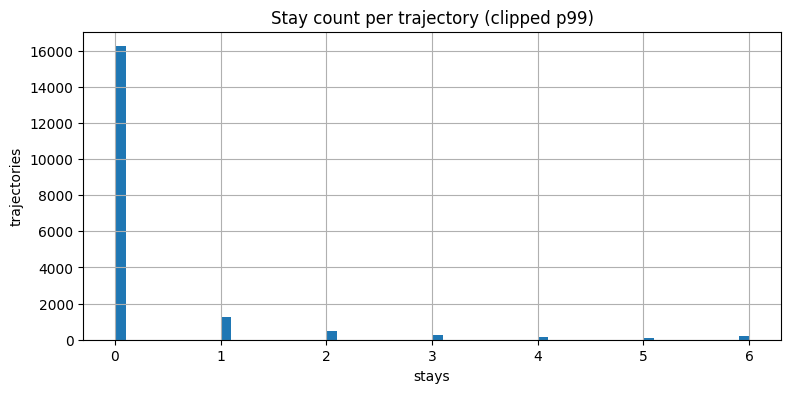

In [11]:
if len(baseline_summary):
    print("Total stays:", int(baseline_summary["n_stays"].sum()))
    print("Files with >=1 stay:", int((baseline_summary["n_stays"] > 0).sum()))
    display(
        baseline_summary[
            [
                "n_sequences",
                "n_stays",
                "temporal_gap_boundaries",
                "hard_speed_boundaries",
            ]
        ].describe()
    )

    fig, ax = plt.subplots(figsize=(9, 4))
    baseline_summary["n_stays"].clip(upper=baseline_summary["n_stays"].quantile(0.99)).hist(
        bins=60, ax=ax
    )
    ax.set(title="Stay count per trajectory (clipped p99)", xlabel="stays", ylabel="trajectories")
    plt.show()


# 8. Sensitivity grid — mechanics smoke check

Grid candidate:

- gap: 120 / 300 / 600 s;
- distance: 100 / 200 / 300 m;
- dwell: 10 / 20 / 30 min;
- tổng cộng 27 configs.

Cell ở notebook 02 chỉ xác nhận mechanics trên một subset nhỏ. **Không dùng kết quả prefix sample này để freeze baseline.**

Lý do: file được sort theo path/user và user activity rất mất cân bằng; lấy `files[:200]` có thể bias mạnh về một nhóm user đầu dataset.

Final sensitivity dùng deterministic user-stratified sample trong **notebook 02b**.

In [12]:
GAPS = [120, 300, 600]
DISTANCES = [100, 200, 300]
DWELLS = [600, 1200, 1800]

grid = pd.DataFrame(
    [(g, d, w) for g in GAPS for d in DISTANCES for w in DWELLS],
    columns=["max_gap_s", "distance_threshold_m", "min_dwell_s"],
)
display(grid)
print("Configs:", len(grid))


,max_gap_s,distance_threshold_m,min_dwell_s
0,120,100,600
1,120,100,1200
2,120,100,1800
3,120,200,600
4,120,200,1200
5,120,200,1800
6,120,300,600
7,120,300,1200
8,120,300,1800
9,300,100,600


Configs: 27


# 9. Sensitivity runner — không phải final evaluation

`SENSITIVITY_FILES = files[:200]` cố ý chỉ là smoke test để kiểm tra loop/config wiring.

### Điều được phép kết luận

- code chạy được trên 27 combinations;
- parameter directions có behavior hợp lý về mặt cơ học.

### Điều không được phép kết luận

- config nào “tốt nhất”;
- user-level robustness;
- Home/Office accuracy.

Final evidence để freeze CP1 nằm ở notebook 02b với 182-user coverage.

In [13]:
SENSITIVITY_FILES = files[:200]

def evaluate_config(paths, max_gap_s, distance_threshold_m, min_dwell_s):
    n_stays = 0
    files_with_stays = 0
    durations = []
    for path in paths:
        cleaned = clean_trajectory(read_plt(path), max_gap_s=max_gap_s)
        stays = detect_staypoints(
            cleaned,
            distance_threshold_m=distance_threshold_m,
            min_dwell_s=min_dwell_s,
        )
        n_stays += len(stays)
        files_with_stays += int(len(stays) > 0)
        if len(stays):
            durations.extend(stays["duration_s"].tolist())
    return {
        "n_stays": n_stays,
        "files_with_stays": files_with_stays,
        "median_duration_s": float(np.median(durations)) if durations else np.nan,
        "p90_duration_s": float(np.quantile(durations, 0.9)) if durations else np.nan,
    }

sensitivity_rows = []
for row in grid.itertuples(index=False):
    metrics = evaluate_config(
        SENSITIVITY_FILES,
        row.max_gap_s,
        row.distance_threshold_m,
        row.min_dwell_s,
    )
    sensitivity_rows.append({**row._asdict(), **metrics})

sensitivity = pd.DataFrame(sensitivity_rows)
display(sensitivity.sort_values(["max_gap_s", "distance_threshold_m", "min_dwell_s"]))


,max_gap_s,distance_threshold_m,min_dwell_s,n_stays,files_with_stays,median_duration_s,p90_duration_s
0,120,100,600,109,48,870.0,1630.0
1,120,100,1200,28,18,1527.5,3280.3
2,120,100,1800,10,9,2279.5,5767.6
3,120,200,600,185,66,825.0,1438.0
4,120,200,1200,41,26,1437.0,2325.0
5,120,200,1800,13,12,2230.0,4184.0
6,120,300,600,258,82,785.0,1405.6
7,120,300,1200,53,32,1456.0,3080.0
8,120,300,1800,17,16,2230.0,4335.0
9,300,100,600,177,66,873.0,1585.0


# 10. Freeze CP1 stay-point baseline

Final decision được thực hiện sau notebook 02b, không phải từ prefix sensitivity ở trên.

Frozen CP1 engineering baseline:

| parameter | value | semantics |
|---|---:|---|
| same-second compactness | 10 m | safe-to-collapse threshold |
| continuity gap | 300 s | break after long unobserved interval |
| hard-speed guard | 1200 km/h | extreme continuity guard |
| stay radius | 200 m | anchor-based membership |
| minimum dwell | 1200 s | sustained stay >=20 min |

Final user-stratified baseline row ở notebook 02b: **478 stays / 89 users with stays / repeated-location user rate 0.7536** trên sample 851 files.

Đây là **engineering baseline**, không phải empirical optimum cho Home/Office accuracy.

# 11. Handoff → Home/Office

CP1 kết thúc ở stay events. Semantic stage phải bắt đầu từ **user-level repeated history**, không từ raw points.

```text
clean trajectories
    ↓
stay points
    ↓
user-level history sufficiency
    ↓
recurring-location representation
    ↓
timezone / geography policy
    ↓
HOME / OFFICE / OTHER evidence + abstention
```

### Correction so với kế hoạch ban đầu

Kế hoạch sớm từng giả định có thể cộng thẳng UTC+8 và dùng DBSCAN như bước clustering sau. Audit CP2 ở notebook 03 đã sửa hai assumption này:

- không blanket `UTC+8` cho toàn release; v1 chỉ dùng `Asia/Shanghai` cho in-region stays của Beijing-focused users;
- DBSCAN 200 m có chaining nên production recurring-location representation đổi sang **complete linkage max diameter 200 m**.

Đây là ví dụ tại sao notebook validation phải lưu lại cả **decision history** chứ không chỉ final code.